# Rent analysis of University City vs All of Philadelphia 

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt

#### University City specific dataset

In [2]:
ucity_df = pd.read_csv('../data/phillyrentdata/university_city_data_extracted.csv') 

Loading in the university city rent data from https://www.city-data.com/neighborhood/University-City-Philadelphia-PA.html

In [3]:
ucity_df.columns
ucity_df.head()
ucity_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   section                103 non-null    str    
 1   metric                 103 non-null    str    
 2   university_city_value  103 non-null    float64
 3   philadelphia_value     19 non-null     float64
 4   unit                   102 non-null    str    
 5   notes                  22 non-null     str    
dtypes: float64(2), str(4)
memory usage: 9.5 KB


Inspecting the column variables and dtypes. Specifically looking for the University City data compared to the Philadelphia data.

In [4]:
ucity = ucity_df[['section', 'metric', 'university_city_value', 'philadelphia_value', 'unit']]
ucity.head(50)

,section,metric,university_city_value,philadelphia_value,unit
0,basic_profile,area_sq_miles,1.351,NaN,square miles
1,basic_profile,population,20221.000,NaN,people
2,basic_profile,population_density,14972.000,11478.0,people per square mile
3,basic_profile,zip_code,19104.000,NaN,NaN
4,basic_profile,male_population,8511.000,NaN,people
5,basic_profile,female_population,11710.000,NaN,people
6,race,white,11498.000,NaN,count
7,race,black,3607.000,NaN,count
8,race,asian,2770.000,NaN,count
9,race,native_hawaiian_and_other_pacific_islander,1439.000,NaN,count


Creating a new data set that only has the variable that we are interested in examining which are: Metrics(rent), university city values, and Philadelphia values.

In this specific set, the rent distribution are broken down into distince categories that make it easier to compare against another area.

Observing this, it is apparent that all of the Philadelphia city wide values are missing.

In [28]:
ucity_filtered = ucity[ucity['metric'].str.contains(
    'rent', case=False, na=False)]

Making a filtered data set that only represents rent which is the foucs of this analysis

In [29]:
ucity_filtered

,section,metric,university_city_value,philadelphia_value,unit
31,rent_distribution,rent_less_than_100,187.0,NaN,renter households
32,rent_distribution,rent_100_to_199,175.0,NaN,renter households
33,rent_distribution,rent_200_to_299,3276.0,NaN,renter households
34,rent_distribution,rent_300_to_399,1403.0,NaN,renter households
35,rent_distribution,rent_400_to_499,649.0,NaN,renter households
36,rent_distribution,rent_500_to_599,248.0,NaN,renter households
37,rent_distribution,rent_600_to_699,642.0,NaN,renter households
38,rent_distribution,rent_700_to_799,618.0,NaN,renter households
39,rent_distribution,rent_800_to_899,172.0,NaN,renter households
40,rent_distribution,rent_900_to_999,1187.0,NaN,renter households


The philadelphia information must be retrieved from another source and then merged into a new table.

## Citywide Philly rent

In [30]:
phillyrent_df = pd.read_csv('../data/phillyrentdata/phillyrent.csv') 

Importing the philly rent data from https://data.census.gov/profile/Philadelphia_city,_Pennsylvania?g=160XX00US4260000

In [31]:
phillyrent_df

,Label (Grouping),"Philadelphia County, Pennsylvania!!Estimate","Philadelphia County, Pennsylvania!!Margin of Error","Philadelphia city, Pennsylvania!!Estimate","Philadelphia city, Pennsylvania!!Margin of Error"
0,Total:,"327,523","±4,547","327,523","±4,547"
1,With cash rent:,"315,745","±4,360","315,745","±4,360"
2,Less than $100,"1,096",±469,"1,096",±469
3,$100 to $149,343,±184,343,±184
4,$150 to $199,"1,480",±406,"1,480",±406
5,$200 to $249,"2,854",±519,"2,854",±519
6,$250 to $299,"6,488",±948,"6,488",±948
7,$300 to $349,"3,509",±614,"3,509",±614
8,$350 to $399,"3,522",±675,"3,522",±675
9,$400 to $449,"3,009",±513,"3,009",±513


In [10]:
citywide_philly_rent = phillyrent_df.rename(columns={
    'Label (Grouping)': 'category',
    'Philadelphia city, Pennsylvania!!Estimate': 'households'
})

Filtering the data set by the rent distribution groupings and the esitmate amount of households that fall under each grouping. Renaming those grouping "catergory" and the estimates "households".

In [12]:
citywide_philly_rent = citywide_philly_rent[['category', 'households']]
citywide_philly_rent

,category,households
0,Total:,"327,523"
1,With cash rent:,"315,745"
2,Less than $100,"1,096"
3,$100 to $149,343
4,$150 to $199,"1,480"
5,$200 to $249,"2,854"
6,$250 to $299,"6,488"
7,$300 to $349,"3,509"
8,$350 to $399,"3,522"
9,$400 to $449,"3,009"


In [15]:
citywide_philly_rent['households'] = (
    citywide_philly_rent['households']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

Changing the category lables from strings into numeric values so the categories can be compared to the university city values which are already as numeric values in the ucity data set.

In [16]:
city_prop = pd.DataFrame({
    'category': [
        'rent_less_than_100',
        'rent_100_to_199',
        'rent_200_to_299',
        'rent_300_to_399',
        'rent_400_to_499',
        'rent_500_to_599',
        'rent_600_to_699',
        'rent_700_to_799',
        'rent_800_to_899',
        'rent_900_to_999',
        'rent_1000_to_1249',
        'rent_1250_to_1499',
        'rent_1500_to_1999',
        'rent_2000_or_more'
    ],
    'citywide_households': [
        citywide_philly_rent.loc[2, 'households'],
        citywide_philly_rent.loc[3:4, 'households'].sum(),
        citywide_philly_rent.loc[5:6, 'households'].sum(),
        citywide_philly_rent.loc[7:8, 'households'].sum(),
        citywide_philly_rent.loc[9:10, 'households'].sum(),
        citywide_philly_rent.loc[11:12, 'households'].sum(),
        citywide_philly_rent.loc[13:14, 'households'].sum(),
        citywide_philly_rent.loc[15:16, 'households'].sum(),
        citywide_philly_rent.loc[17, 'households'],
        citywide_philly_rent.loc[18, 'households'],
        citywide_philly_rent.loc[19, 'households'],
        citywide_philly_rent.loc[20, 'households'],
        citywide_philly_rent.loc[21, 'households'],
        citywide_philly_rent.loc[22:25, 'households'].sum()
    ]
})

As the numbers are quite large, comparing the proportion of households that fall under each rent distribution, from both all of philly and just university, will provide a more accurate analysis of how the the areas differ. 

# Comparison

In [17]:
city_prop['citywide_proportion'] = (
    city_prop['citywide_households'] / city_prop['citywide_households'].sum()
)

city_prop

,category,citywide_households,citywide_proportion
0,rent_less_than_100,1096.0,0.003471
1,rent_100_to_199,1823.0,0.005774
2,rent_200_to_299,9342.0,0.029587
3,rent_300_to_399,7031.0,0.022268
4,rent_400_to_499,5801.0,0.018372
5,rent_500_to_599,5221.0,0.016535
6,rent_600_to_699,5966.0,0.018895
7,rent_700_to_799,8542.0,0.027053
8,rent_800_to_899,12679.0,0.040156
9,rent_900_to_999,16546.0,0.052403


Converting the amount of city wide households into proportions.

We can see that most of the rent in philadelphia is concentrated in the $1500 to $1999 range.

In [24]:
ucity_rent = ucity_filtered[ucity_filtered['section'] == 'rent_distribution'].copy()

ucity_rent = ucity_rent[['metric', 'university_city_value']]

ucity_rent['ucity_proportion'] = (
    ucity_rent['university_city_value'] / ucity_rent['university_city_value'].sum()
)

ucity_rent

,metric,university_city_value,ucity_proportion
31,rent_less_than_100,187.0,0.009940
32,rent_100_to_199,175.0,0.009303
33,rent_200_to_299,3276.0,0.174144
34,rent_300_to_399,1403.0,0.074580
35,rent_400_to_499,649.0,0.034499
36,rent_500_to_599,248.0,0.013183
37,rent_600_to_699,642.0,0.034127
38,rent_700_to_799,618.0,0.032851
39,rent_800_to_899,172.0,0.009143
40,rent_900_to_999,1187.0,0.063098


Now converting the amount of university city households into proportions.

From this table, it is shown that most of the rent in university city is concentrated in the $1000 to $1249 range.

In [32]:
rent_comparison = ucity_rent.copy()

rent_comparison['citywide_proportion'] = city_prop['citywide_proportion'].values

rent_comparison['ucity_percent'] = rent_comparison['ucity_proportion'] * 100
rent_comparison['citywide_percent'] = rent_comparison['citywide_proportion'] * 100

rent_comparison[['metric', 'ucity_percent', 'citywide_percent']]

,metric,ucity_percent,citywide_percent
31,rent_less_than_100,0.994046,0.347116
32,rent_100_to_199,0.930257,0.577365
33,rent_200_to_299,17.414416,2.958717
34,rent_300_to_399,7.458006,2.226797
35,rent_400_to_499,3.449926,1.837242
36,rent_500_to_599,1.318307,1.653550
37,rent_600_to_699,3.412715,1.889499
38,rent_700_to_799,3.285137,2.705348
39,rent_800_to_899,0.914310,4.015582
40,rent_900_to_999,6.309802,5.240305


In [ ]:
Merging the proportions into the same table.

<Axes: xlabel='metric'>

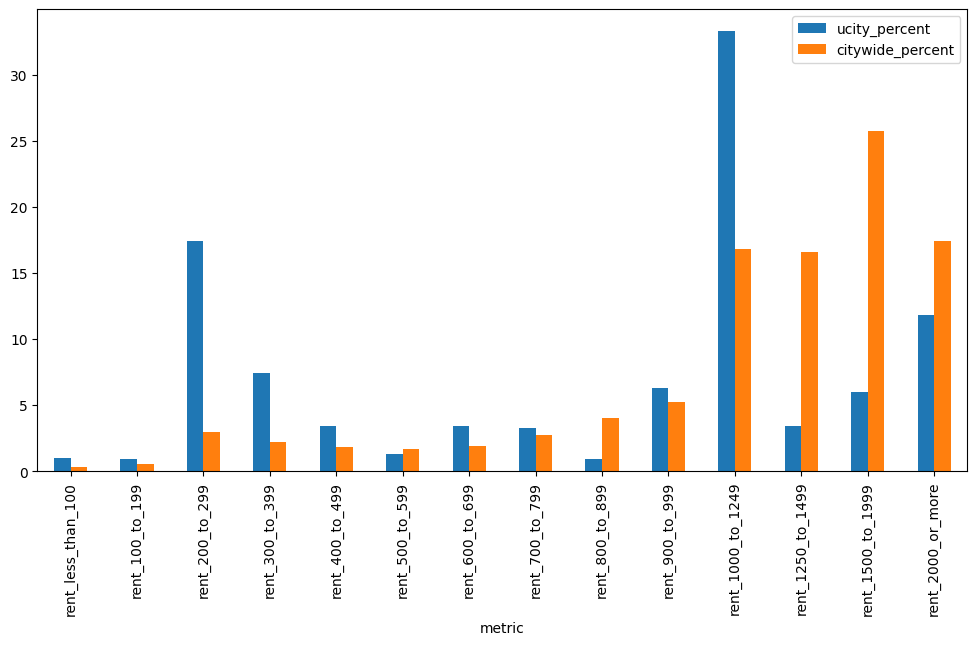

In [26]:
rent_comparison.plot(
    x='metric',
    y=['ucity_percent', 'citywide_percent'],
    kind='bar',
    figsize=(12,6)
)

Visualizing the data within a bar chart which allows us to see how the proportions of rent within University city and the entirety of Philly compare against each other.

# Main Takeaway

University City's rental market is heavily shaped by Penn and Drexel in ways that set it apart from Philadelphia overall. The neighborhood clusters at two distinct price points: the lower-mid ranges ($200–$399), most likely driven by shared housing and student-friendly pricing, and around $1,000–$1,249, likely a sweet spot for off-campus students and recent grads staying close to campus. Philadelphia as a whole skews higher, with more renters in the $1,250–$1,499, $1,500–$1,999, and $2,000+ tiers. This group of more expensive homes may reflect a broader market that is less influenced by student demand.

The pattern makes clear that universities don't just define a neighborhood academically, they shape its housing market too. Overall this creates a two-tiered rental landscape.